# **EDA Notebook Product List Price History**



---
## 0. Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 106.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data


---
## Student Information

In [2]:
group_name = "20"
student_name = "Shanu Sharma"
student_id = "25979360"

In [3]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [6]:
# No additional packages required for this EDA notebook.

### 0.b Import Packages

In [7]:
# Import packages used for data inspection and plotting.
import pandas as pd
from matplotlib import pyplot as plt

---
## B. Data Understanding

In [8]:
# Do not modify this code
try:
  df = pd.read_csv(at.folder_path / "product_list_price_history.csv")
except Exception as e:
  print(e)

### B.1 Explore Dataset

In [9]:
# Preview records and inspect the raw product list price history table.
display(df.head())

print(f"Raw rows and columns: {df.shape}")
print(f"Duplicate raw rows: {df.duplicated().sum()}")

print("Raw missing values:")
display(df.isna().sum())

print("Raw unique values:",'\n')
display(df.nunique())

print("Raw list price summary:")
display(df["list_price"].describe().round(2))

,product_id,start_date,end_date,list_price
0,d8f1ff26-6a35-4e95-814b-de35bdd87ce0,2012-05-30 00:00:00,2013-05-29 00:00:00,44.9900
1,ce0a0304-eeaf-4032-b4ae-1a31c74ce76b,2013-05-30 00:00:00,NaN,539.9900
2,9014b398-fe53-4fb0-8177-97347cea83c3,2013-05-30 00:00:00,NaN,2294.9900
3,05385566-38df-4855-94a8-786cae6ffe49,2011-05-31 00:00:00,2012-05-29 00:00:00,33.6442
4,9e4e275e-baa1-44e2-827e-ec3fead348fa,2013-05-30 00:00:00,NaN,NaN


Raw rows and columns: (620, 4)
Duplicate raw rows: 225
Raw missing values:


,0
product_id,0
start_date,22
end_date,311
list_price,145


Raw unique values: 



,0
product_id,293
start_date,3
end_date,2
list_price,112


Raw list price summary:


,list_price
count,475.00
mean,736.67
std,848.74
min,2.29
25%,60.74
50%,348.76
75%,1120.49
max,3578.27


In [10]:
# Create analysis tables: one deduplicated table and one valid price table.
price_history_base = df.drop_duplicates().copy()
valid_price_base = price_history_base.dropna(subset=["list_price"]).copy()

price_history = price_history_base.assign(
    start_date_dt=pd.to_datetime(price_history_base["start_date"]),
    end_date_dt=pd.to_datetime(price_history_base["end_date"]),
)
price_history = price_history.assign(is_current_price=price_history["end_date_dt"].isna())

valid_price_history = valid_price_base.assign(
    start_date_dt=pd.to_datetime(valid_price_base["start_date"]),
    end_date_dt=pd.to_datetime(valid_price_base["end_date"]),
)
valid_price_history = valid_price_history.assign(
    is_current_price=valid_price_history["end_date_dt"].isna()
)

print(f"Deduplicated original rows and columns: {price_history_base.shape}")
print(f"Valid non-null price rows and columns before derived fields: {valid_price_base.shape}")
print(f"Valid EDA working table after derived date fields: {valid_price_history.shape}")

print("Deduplicated missing values:")
display(price_history_base[["product_id", "start_date", "end_date", "list_price"]].isna().sum())

print("Current versus historical price records in valid table:")
display(valid_price_history["is_current_price"].value_counts())

Deduplicated original rows and columns: (395, 4)
Valid non-null price rows and columns before derived fields: (328, 4)
Valid EDA working table after derived date fields: (328, 7)
Deduplicated missing values:


,0
product_id,0
start_date,6
end_date,200
list_price,67


Current versus historical price records in valid table:


,count
is_current_price,
True,167
False,161


In [11]:
dataset_insights = """
The product_list_price_history dataset contains 620 raw rows and 4 columns: product_id, start_date, end_date, and list_price. Each row represents a list price for a product during a time period. For the clustering analysis, this dataset adds the selling-price side of product behaviour.

Unlike product_cost_history, this dataset has notable data-quality issues. There are 225 duplicate raw rows, so the deduplicated table has 395 rows. The raw dataset also has missing values in start_date, end_date, and list_price. Missing end_date can represent the current active price, but missing list_price cannot be used directly for pricing features. After deduplication and removing missing list_price values, the valid price table contains 328 rows and 253 products.

For margin-risk product clustering, list price history is useful because it helps describe product price positioning and potential margin when combined with product_cost_history. After cleaning, list_price can support product-level features such as latest list price, average list price, price range, and price-change indicators.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.2 Explore Feature of Interest `product_id`

In [13]:
# Count how many valid price records exist for each product.
product_price_counts = (
    valid_price_history.groupby("product_id")
    .size()
    .reset_index(name="num_price_records")
    .sort_values("num_price_records", ascending=False)
)

display(product_price_counts.head(10))
display(product_price_counts["num_price_records"].describe().round(2))
display(product_price_counts["num_price_records"].value_counts().sort_index())

,product_id,num_price_records
10,05385566-38df-4855-94a8-786cae6ffe49,3
53,36847649-a79a-4f70-9b5d-5c403627ab75,3
48,33383d99-db78-414e-a552-f1c3a3937aee,3
50,34ad3302-abb1-4d4d-9f75-b1c0c5919313,3
63,403add96-5ffc-4c2f-888f-0358e9bd36f0,3
121,7a834851-088a-478f-a8a6-099c64e3323f,3
240,f33d8a41-b92f-4f2a-8f75-76ea2f25722b,3
220,d8f138f9-478a-4494-9eff-60324ce60d13,3
174,a2eabbb9-7096-4d1e-be0e-06be8259a129,3
161,99e67c08-395b-4561-91d4-6b7c68427b63,3


,num_price_records
count,253.00
mean,1.30
std,0.56
min,1.00
25%,1.00
50%,1.00
75%,1.00
max,3.00


,count
num_price_records,
1,191
2,49
3,13


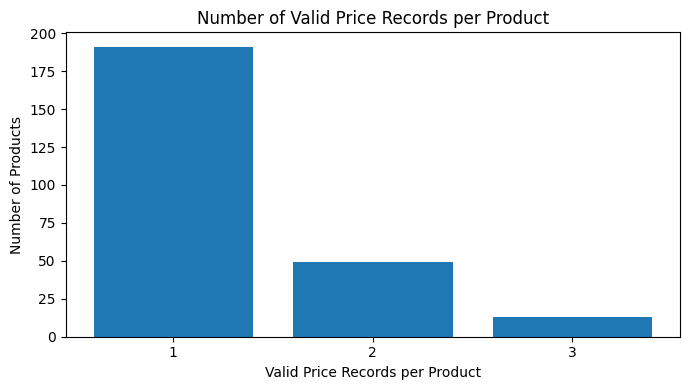

In [14]:
# Plot the number of valid price records per product.
price_record_counts = product_price_counts["num_price_records"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(price_record_counts.index.astype(str), price_record_counts.values)
plt.title("Number of Valid Price Records per Product")
plt.xlabel("Valid Price Records per Product")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

In [15]:
feature_1_insights = """
product_id identifies the products that have list price history. The raw table contains 293 unique products, but after removing duplicate rows and excluding missing list_price values, 253 products have valid price records for analysis.

Most products have only one valid price record: 191 products have one record, 49 products have two records, and 13 products have three records. For the retailer, this suggests that most products have stable or limited price-history information, while a smaller group has multiple price records that can indicate price changes.

For final margin-risk clustering, product_id should be used as the aggregation key, not as a modelling feature. The useful product-level features are derived from price history, such as num_price_records, latest_list_price, min_list_price, max_list_price, and price_range.
"""

In [16]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### B.3 Explore Feature of Interest `list_price`

In [17]:
# Analyse list_price using the deduplicated valid price table.
display(valid_price_history["list_price"].describe().round(2))

display(valid_price_history[[
    "product_id",
    "start_date",
    "end_date",
    "list_price",
    "is_current_price",
]].sort_values("list_price", ascending=False).head(10))

,list_price
count,328.00
mean,740.87
std,830.58
min,2.29
25%,68.37
50%,360.58
75%,1194.46
max,3578.27


,product_id,start_date,end_date,list_price,is_current_price
249,41b7b226-20ea-488a-b519-b4ca65d4a64e,2011-05-31 00:00:00,2012-05-29 00:00:00,3578.27,False
617,e8c12ae4-8042-4b77-8bd7-023d46440e33,2011-05-31 00:00:00,2012-05-29 00:00:00,3578.27,False
124,01225971-c68c-4650-8d3c-f498ece3c5da,2011-05-31 00:00:00,2012-05-29 00:00:00,3578.27,False
518,378b5732-eba9-46e4-a6c1-4040717835d5,2011-05-31 00:00:00,2012-05-29 00:00:00,3578.27,False
482,a16ed5b0-74c7-4812-adea-04b4abfd72c7,2011-05-31 00:00:00,2012-05-29 00:00:00,3399.99,False
356,a8fcee30-f73d-42fb-a1bb-95d5e9e66a86,2011-05-31 00:00:00,2012-05-29 00:00:00,3399.99,False
140,6cc3d977-da73-4856-b1ca-8a2f0b57b60b,2011-05-31 00:00:00,2012-05-29 00:00:00,3399.99,False
128,de8b1961-ea0e-4639-9482-7f71b3ed07d8,2011-05-31 00:00:00,2012-05-29 00:00:00,3374.99,False
337,852af53a-5738-432c-90c9-41e230990102,2011-05-31 00:00:00,2012-05-29 00:00:00,3374.99,False
47,03342abf-54b7-47ae-be8c-eafd20fb2d1c,2011-05-31 00:00:00,2012-05-29 00:00:00,3374.99,False


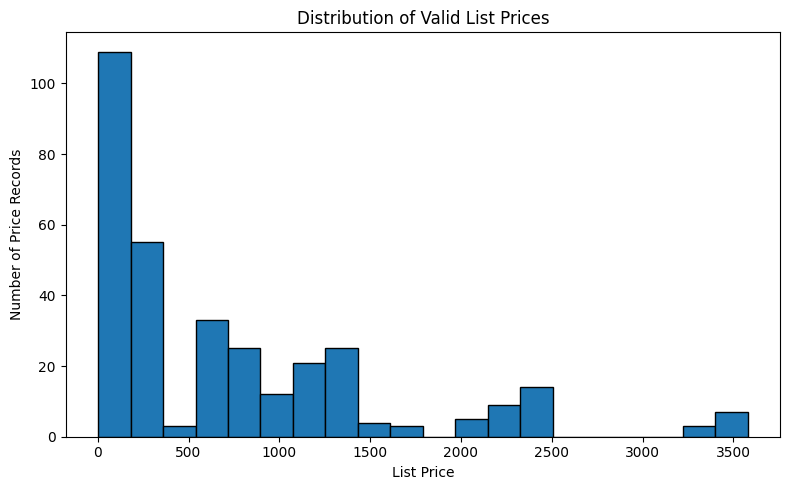

In [18]:
# Plot the list price distribution.
plt.figure(figsize=(8, 5))
plt.hist(valid_price_history["list_price"], bins=20, edgecolor="black")
plt.title("Distribution of Valid List Prices")
plt.xlabel("List Price")
plt.ylabel("Number of Price Records")
plt.tight_layout()
plt.show()

In [19]:
feature_2_insights = """
list_price represents the advertised selling price before discounts. In the deduplicated valid price table, list_price ranges from 2.29 to 3578.27, with a mean of about 740.87 and a median of about 360.58. The mean is much higher than the median, which shows that list_price is right-skewed and includes some very high-price products.

For the product-level clustering workflow, list_price is a candidate signal for distinguishing premium and low-price products, and for later interpreting whether discounts may have different commercial effects across clusters. A discount on a high-price product may have a larger revenue or margin impact than a discount on a low-price product. The skewed price distribution also means price features should be scaled before clustering so high dollar values do not dominate other product features.

For final margin-risk product clustering, list_price should be aggregated to product level and combined with cost and promotion features. Useful derived features include latest_list_price, average_list_price, min_list_price, max_list_price, and estimated margin features after joining with product_cost_history.
"""

In [20]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.4 Grouped Analysis: Price Stability and Connection to Cost and Promotion

In [21]:
# Build product-level price stability features.
product_price_summary = (
    valid_price_history.groupby("product_id")
    .agg(
        num_price_records=("list_price", "size"),
        min_list_price=("list_price", "min"),
        max_list_price=("list_price", "max"),
        latest_start_date=("start_date_dt", "max"),
    )
    .reset_index()
    .assign(lambda_price_range=lambda x: x["max_list_price"] - x["min_list_price"])
    .rename(columns={"lambda_price_range": "price_range"})
)

display(product_price_summary.sort_values("price_range", ascending=False).head(10))
display(product_price_summary["price_range"].describe().round(2))
print(f"Products with price changes: {(product_price_summary['price_range'] > 0).sum()}")
changed_price = product_price_summary.loc[product_price_summary["price_range"] > 0, "price_range"]
print(f"Median price range among products with a price change: {changed_price.median():.2f}")

,product_id,num_price_records,min_list_price,max_list_price,latest_start_date,price_range
29,1bb0beb1-9648-4bb3-9217-d41d4c5dfa2e,2,2181.5625,2443.35,2013-05-30,261.7875
35,205e08a5-a262-40f2-910b-6143b321646e,2,2181.5625,2443.35,2013-05-30,261.7875
210,d002fd5b-09c8-48db-8d8f-75991c5021d0,2,2181.5625,2443.35,2013-05-30,261.7875
216,d57b0ea4-b670-4c7b-85ac-29305f9c7f5c,2,2181.5625,2443.35,2013-05-30,261.7875
57,3ab2259b-bc23-42ad-8bfc-d0d985465644,2,2071.4196,2319.99,2013-05-30,248.5704
70,4550cbe3-c033-4b22-af8b-7b00e8173f95,2,2071.4196,2319.99,2013-05-30,248.5704
188,bb3cdc8c-7863-49eb-bb57-d59ba5ee6121,2,2071.4196,2319.99,2013-05-30,248.5704
151,9014b398-fe53-4fb0-8177-97347cea83c3,2,2049.0982,2294.99,2013-05-30,245.8918
200,c62cc174-c497-4da7-8d2a-5a5068c9d246,2,1263.4598,1431.50,2013-05-30,168.0402
202,c8916792-ee6b-4051-9c4e-331984afb135,2,1263.4598,1431.50,2013-05-30,168.0402


,price_range
count,253.00
mean,22.22
std,56.25
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,261.79


Products with price changes: 62
Median price range among products with a price change: 83.89


In [22]:
# Check overlap with cost history and offer-product mapping.
product_cost_history = pd.read_csv(at.folder_path / "product_cost_history.csv")
special_offer_product = pd.read_csv(at.folder_path / "special_offer_product.csv")

price_products = set(valid_price_history["product_id"].unique())
cost_products = set(product_cost_history["product_id"].unique())
offer_products = set(special_offer_product["product_id"].unique())

print(f"Products with valid price history: {len(price_products)}")
print(f"Products in cost history: {len(cost_products)}")
print(f"Products in special_offer_product: {len(offer_products)}")
print(f"Products with valid price and cost history: {len(price_products & cost_products)}")
print(f"Products with valid price and offer mapping: {len(price_products & offer_products)}")
print(f"Offer-linked products without valid price history: {len(offer_products - price_products)}")

Products with valid price history: 253
Products in cost history: 293
Products in special_offer_product: 295
Products with valid price and cost history: 253
Products with valid price and offer mapping: 253
Offer-linked products without valid price history: 42


In [23]:
feature_n_insights = """
The grouped analysis shows that 62 products have price changes in the valid price history, measured by a positive price_range. Among products with price changes, the median price_range is about 83.89 and the maximum price_range is about 261.79. Most products have no observed price change after cleaning, but the products with price changes may represent repositioning, pricing updates, or products that could need closer pricing review after cluster profiling.

The connection to previous notebooks is through product_id. There are 253 products with valid price history, and all 253 also appear in both product_cost_history and special_offer_product. However, 42 offer-linked products do not have valid list price history. Checked against the 254 sales-active products from sales_order_detail, 33 of those 254 products have no valid list price record. These 33 products are retained in the modelling population and their price and margin features are imputed in the preparation step.

For the final margin-risk product clustering solution, product_list_price_history completes the commercial picture. Together with product_cost_history and promotion exposure from special_offer_product/special_offer, it allows the retailer to discover product groups with different price positions, cost structures, promotion behaviour, and margin-related risk patterns.
"""

In [24]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)